# Detecting Emerging Drug Activity Clusters
### A Machine Learning Approach Using Growth Thresholds and HistGradientBoosting


<img src="map.png" style="display: block; margin: auto;">

### Import libraries and define dataset source
In this cell we import all Python libraries needed for data handling, feature engineering, and machine learning. It also documents the source of the dataset used in this project.

In [19]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

# data is from here 
# https://catalog.data.gov/dataset/crime-reports-bf2b7


### Define configuration and modeling assumptions

Define global configuration values such as the input file path,
columns to load, thresholds for defining an emerging cluster, and a simulated
"current year" used to restrict the analysis period.

In [20]:
DATA_PATH = "Crime_Reports.csv"   

# Columns needed for this analysis
USECOLS = [
    "Occurred Date",
    "Highest Offense Description",
    "APD Sector",
    "APD District",
    "Location Type",
]

MIN_COUNT = 5           # minimum incidents in month to consider that month "active"
GROWTH_Q = 0.75         # percentile for local growth threshold (per district-year)
SPLIT_DATE_STR = "2019-01-01"  # train on months before this date, test on months after
RANDOM_STATE = 42
SIM_CURRENT_YEAR = 2018 # year used for "current-year" emerging zone simulation

### Load crime data and filter to drug-related offenses

This is where we load the crime report CSV, keep only the columns we care about, drop rows missing zone information, and filter to incidents that appear to be drug-related based on the offense description.

In [21]:
# Read only selected columns 
df = pd.read_csv(DATA_PATH, usecols=USECOLS)

# Keep only rows with valid information
df = df.dropna(subset=["APD Sector", "APD District"])

# Keep incidents whose offense description indicates drug related activities
mask = df["Highest Offense Description"].str.contains(
    "DRUG|NARCOTIC|CONTROLLED SUB|PARAPHERNALIA",
    case=False,
    na=False,
)
df = df[mask]

print(f"Drug-only row: {len(df):,}")
df

Drug-only row: 93,438


,Highest Offense Description,Occurred Date,Location Type,APD Sector,APD District
7,POSS OF DRUG PARAPHERNALIA,01/01/2003,HWY / ROAD / ALLEY/ STREET/ SIDEWALK,GE,3
21,POSS CONTROLLED SUB/NARCOTIC,01/01/2003,PARKING /DROP LOT/ GARAGE,HE,3
23,POSS OF DRUG PARAPHERNALIA,01/01/2003,HOTEL / MOTEL / ETC.,AD,4
34,POSS CONTROLLED SUB/NARCOTIC,01/01/2003,RESIDENCE / HOME,BA,5
118,POSS CONTROLLED SUB/NARCOTIC,01/01/2003,FIELD / WOODS,GE,3
...,...,...,...,...,...
2597915,POSS OF DRUG PARAPHERNALIA,12/02/2005,HOTEL / MOTEL / ETC.,BA,4
2597926,POSS CONTROLLED SUB/NARCOTIC,08/29/2006,NaN,DA,10
2597970,POSS OF DRUG PARAPHERNALIA,07/15/2018,HWY / ROAD / ALLEY/ STREET/ SIDEWALK,CH,3
2598044,POSS CONTROLLED SUB/NARCOTIC,04/06/2004,PARKING /DROP LOT/ GARAGE,ED,1


### Create time and zone features

This cell:
- Converts the `Occurred Date` column to a proper datetime type
- Creates `YearMonth` (period) and `Year` columns
- Builds a combined `APD_Zone` from sector and district
- Fills missing `Location Type` values
These features will be used to aggregate incidents and build the prediction model.

In [22]:
# Parse Occured Date as a datetime. Invalid entried become NaT
df["Occurred Date"] = pd.to_datetime(df["Occurred Date"], errors="coerce") # turns occured date data type to datetime

# Drop incidents with no valid occurence date
df = df.dropna(subset=["Occurred Date"]) 

# Monthly time index and calendar year for each incident
df["YearMonth"] = df["Occurred Date"].dt.to_period("M") 
df["Year"] = df["Occurred Date"].dt.year 

# Define APD_Zone as Sector_District 
df["APD_Zone"] = df["APD Sector"].astype(str) + "_" + df["APD District"].astype(str) # combine apd sector and apd district to a new column

# Replace mising location with an "UNKNOWN" as a filler string
df["Location Type"] = df["Location Type"].fillna("UNKNOWN") # looks at NaN in location type and files it with "unknown"

df

,Highest Offense Description,Occurred Date,Location Type,APD Sector,APD District,YearMonth,Year,APD_Zone
7,POSS OF DRUG PARAPHERNALIA,2003-01-01,HWY / ROAD / ALLEY/ STREET/ SIDEWALK,GE,3,2003-01,2003,GE_3
21,POSS CONTROLLED SUB/NARCOTIC,2003-01-01,PARKING /DROP LOT/ GARAGE,HE,3,2003-01,2003,HE_3
23,POSS OF DRUG PARAPHERNALIA,2003-01-01,HOTEL / MOTEL / ETC.,AD,4,2003-01,2003,AD_4
34,POSS CONTROLLED SUB/NARCOTIC,2003-01-01,RESIDENCE / HOME,BA,5,2003-01,2003,BA_5
118,POSS CONTROLLED SUB/NARCOTIC,2003-01-01,FIELD / WOODS,GE,3,2003-01,2003,GE_3
...,...,...,...,...,...,...,...,...
2597915,POSS OF DRUG PARAPHERNALIA,2005-12-02,HOTEL / MOTEL / ETC.,BA,4,2005-12,2005,BA_4
2597926,POSS CONTROLLED SUB/NARCOTIC,2006-08-29,UNKNOWN,DA,10,2006-08,2006,DA_10
2597970,POSS OF DRUG PARAPHERNALIA,2018-07-15,HWY / ROAD / ALLEY/ STREET/ SIDEWALK,CH,3,2018-07,2018,CH_3
2598044,POSS CONTROLLED SUB/NARCOTIC,2004-04-06,PARKING /DROP LOT/ GARAGE,ED,1,2004-04,2004,ED_1


### Aggregate incidents by zone and month

Here we count the number of drug-related incidents per:
- APD Zone
- APD District
- YearMonth

We also convert the YearMonth period to a timestamp `YM_ts` that is convenient
for splitting into train/test and for computing lag features.

In [23]:
monthly = (
    df.groupby(["APD_Zone", "APD District", "YearMonth"])
      .size()
      .reset_index(name="count")
      .sort_values(["APD_Zone", "YearMonth"])
      .copy() # avoid setting warning
)
 
# Convert YearMonth period to a timestamp for time-based splitting 
monthly["YM_ts"] = monthly["YearMonth"].dt.to_timestamp() 

print(f"Monthly zone rows: {len(monthly):,}")
monthly

Monthly zone rows: 15,862


,APD_Zone,APD District,YearMonth,count,YM_ts
0,88_88,88,2003-01,3,2003-01-01
1,88_88,88,2003-02,3,2003-02-01
2,88_88,88,2003-03,1,2003-03-01
3,88_88,88,2003-04,1,2003-04-01
4,88_88,88,2003-07,6,2003-07-01
...,...,...,...,...,...
15857,UT_C,C,2017-01,1,2017-01-01
15858,UT_C,C,2018-03,1,2018-03-01
15859,UT_C,C,2019-11,1,2019-11-01
15860,UT_C,C,2019-12,1,2019-12-01


### Add lagged counts and growth features
This cell computes:
- `prev_count`: the previous month's incident count for each zone
- `growth`: the month-over-month relative change in incident count

We then drop rows where a previous month is not available.

In [24]:
# Previous month's incident count within each zone
monthly["prev_count"] = (
    monthly.groupby("APD_Zone")["count"].shift(1)
) 

# Smoothed growth rate relative to previous month
# (add 1 to avoid division by zero when prev_count = 0)
monthly["growth"] = (
    (monthly["count"] - monthly["prev_count"]) 
    / (monthly["prev_count"] + 1)
) 

# Drop the first month in each zone when no previous month available
monthly = monthly.dropna(subset=["prev_count"])

monthly

,APD_Zone,APD District,YearMonth,count,YM_ts,prev_count,growth
1,88_88,88,2003-02,3,2003-02-01,3.0,0.000000
2,88_88,88,2003-03,1,2003-03-01,3.0,-0.500000
3,88_88,88,2003-04,1,2003-04-01,1.0,0.000000
4,88_88,88,2003-07,6,2003-07-01,1.0,2.500000
5,88_88,88,2003-08,3,2003-08-01,6.0,-0.428571
...,...,...,...,...,...,...,...
15857,UT_C,C,2017-01,1,2017-01-01,1.0,0.000000
15858,UT_C,C,2018-03,1,2018-03-01,1.0,0.000000
15859,UT_C,C,2019-11,1,2019-11-01,1.0,0.000000
15860,UT_C,C,2019-12,1,2019-12-01,1.0,0.000000


### Compute district-year growth thresholds
We now compute, for each APD district and year, a local growth threshold based on the `GROWTH_Q` quantile. This threshold is later used to label months as emerging clusters if their growth exceeds this local benchmark.

In [25]:
# Ensure we have Year for each monthly row
monthly["Year"] = monthly["YM_ts"].dt.year

def compute_local_threshold(subdf):
    '''
    Computer the local growth threshold for a given group (distric, year).
    Uses only months with at least MIN_COUNT incidents to avoid noise, 
    and returns the GROWTH_Q percentile of the growth distribution.
    '''
    valid = subdf[subdf["count"] >= MIN_COUNT]
    if valid.empty:
        return np.nan
    return valid["growth"].quantile(GROWTH_Q)

# One growth threshold per ADP District and Year
district_thresholds = (
    monthly.groupby(["APD District", "Year"])[["count", "growth"]]
           .apply(compute_local_threshold)
           .reset_index(name="growth_thresh")
)

# Attach district-year growth threshold back onto monthly dataframe
monthly = monthly.merge(
    district_thresholds,
    on=["APD District", "Year"],
    how="left"
)

print("Sample of district-year growth thresholds:")
print(district_thresholds[district_thresholds['growth_thresh']>=0])
monthly

Sample of district-year growth thresholds:
    APD District  Year  growth_thresh
4              1  2003       0.440994
5              1  2004       0.404167
6              1  2005       0.446429
7              1  2006       0.500000
8              1  2007       0.458333
..           ...   ...            ...
290            S  2003       0.416667
291            S  2004       0.800000
292            S  2005       0.343750
293            S  2006       1.333333
296            S  2009       2.000000

[200 rows x 3 columns]


C:\Users\Andres Navarrete\AppData\Local\Temp\ipykernel_7784\1794378729.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly["Year"] = monthly["YM_ts"].dt.year


,APD_Zone,APD District,YearMonth,count,YM_ts,prev_count,growth,Year,growth_thresh
0,88_88,88,2003-02,3,2003-02-01,3.0,0.000000,2003,2.5
1,88_88,88,2003-03,1,2003-03-01,3.0,-0.500000,2003,2.5
2,88_88,88,2003-04,1,2003-04-01,1.0,0.000000,2003,2.5
3,88_88,88,2003-07,6,2003-07-01,1.0,2.500000,2003,2.5
4,88_88,88,2003-08,3,2003-08-01,6.0,-0.428571,2003,2.5
...,...,...,...,...,...,...,...,...,...
15766,UT_C,C,2017-01,1,2017-01-01,1.0,0.000000,2017,NaN
15767,UT_C,C,2018-03,1,2018-03-01,1.0,0.000000,2018,NaN
15768,UT_C,C,2019-11,1,2019-11-01,1.0,0.000000,2019,NaN
15769,UT_C,C,2019-12,1,2019-12-01,1.0,0.000000,2019,NaN


### Label emerging drug clusters
Using the `MIN_COUNT` and the computed `growth_thresh`, this cell labels each (zone, month) as an emerging cluster (`IsEmergingCluster = 1`) if:
- the incident count that month is at least `MIN_COUNT`, and
- the growth is greater than or equal to the local district-year threshold.

In [26]:
# A month is labeled as "emerging" if :
# it has enough incidents (>= MIN_COUNT), and
# its growth exceeds the local district-year growth threshold
monthly["IsEmergingCluster"] = (
    (monthly["count"] >= MIN_COUNT) &               # enough incidents this month
    (monthly["growth"] >= monthly["growth_thresh"]) # growth above local threshold
).astype(int)

print("Positive class rate:", monthly["IsEmergingCluster"].mean())
print(monthly[monthly['IsEmergingCluster'] == 1])

Positive class rate: 0.1041785555766914
      APD_Zone APD District YearMonth  count      YM_ts  prev_count    growth  \
3        88_88           88   2003-07      6 2003-07-01         1.0  2.500000   
18       88_88           88   2004-10      5 2004-10-01         3.0  0.500000   
30       88_88           88   2006-01      5 2006-01-01         1.0  2.000000   
50       88_88           88   2007-10      5 2007-10-01         2.0  1.000000   
54       88_88           88   2008-02      5 2008-02-01         4.0  0.200000   
...        ...          ...       ...    ...        ...         ...       ...   
15645     ID_8            8   2019-05      8 2019-05-01         6.0  0.285714   
15650     ID_8            8   2019-10      8 2019-10-01         6.0  0.285714   
15654     ID_8            8   2020-02      8 2020-02-01         3.0  1.250000   
15674     ID_8            8   2022-02      5 2022-02-01         1.0  2.000000   
15695     ID_8            8   2024-03      6 2024-03-01         1.0  

### Split data into train and test sets and select features
We split the aggregated monthly data into train and test sets based on `YM_ts`
and `SPLIT_DATE_STR`. We then define:
- numerical features (`count`, `prev_count`, `growth`)
- categorical features (`APD_Zone`)
- target (`IsEmergingCluster`)

In [ ]:
# Split by time so the model predicts future months from past behavior
split_date = pd.to_datetime(SPLIT_DATE_STR)

train = monthly[monthly["YM_ts"] < split_date].copy()
test  = monthly[monthly["YM_ts"] >= split_date].copy()

# Numberical predictors capturing level and change
feature_numerical = ["count", "prev_count", "growth"]

# Categorical predictor for region
feature_categorical = ["APD_Zone"]

# Binary target 1 = emerging cluster and 0 = not emerging
target = "IsEmergingCluster"

X_train = train[feature_numerical + feature_categorical]
y_train = train[target]

X_test = test[feature_numerical + feature_categorical]
y_test = test[target]

print("\nTrain size:", X_train.shape, "Test size:", X_test.shape)
X_train



Train size: (11313, 4) Test size: (4458, 4)


,count,prev_count,growth,APD_Zone
0,3,3.0,0.000000,88_88
1,1,3.0,-0.500000,88_88
2,1,1.0,0.000000,88_88
3,6,1.0,2.500000,88_88
4,3,6.0,-0.428571,88_88
...,...,...,...,...
15763,1,1.0,0.000000,UT_C
15764,1,1.0,0.000000,UT_C
15765,1,1.0,0.000000,UT_C
15766,1,1.0,0.000000,UT_C


### Build preprocessing pipeline, train the model, and evaluate
Here we: 
- Define a `ColumnTransformer` that one-hot encodes categorical features and
  passes numerical features through unchanged.
- Use a `HistGradientBoostingClassifier` as the prediction model.
- Combine preprocessing and model into a single pipeline.
- Fit the model on the training data and evaluate it on the test data using
  a classification report and confusion matrix.

In [28]:
# One-hot endoce APD_zone and pass numerical features through unchanged
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessing = ColumnTransformer(
    transformers=[
        ("categorical", ohe, feature_categorical), # encode APD_Zone
        ("nummerical", "passthrough", feature_numerical), # keep numeric features 
    ],
    remainder="drop" # drop everything else
)

# Run model HistGradientBoostingClassifier
model = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.1,
    max_iter=300,
    random_state=RANDOM_STATE
)

# Make pipeline for preprocessing and model
pipe = make_pipeline(preprocessing, model)

# Fit model on pre-2019 data ad evaluate 2019+ data
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)


# Reports metrics for correct emergence of each month per zone
print("=== Classification Report (Local Emerging Label) ===")
print(classification_report(y_test, y_pred, digits=3))
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

=== Classification Report (Local Emerging Label) ===
              precision    recall  f1-score   support

           0      0.993     0.978     0.985      4117
           1      0.772     0.915     0.838       341

    accuracy                          0.973      4458
   macro avg      0.883     0.946     0.911      4458
weighted avg      0.976     0.973     0.974      4458

=== Confusion Matrix ===
[[4025   92]
 [  29  312]]


Best learning_rate: 0.010000
Minimum CV log-loss: 0.074181


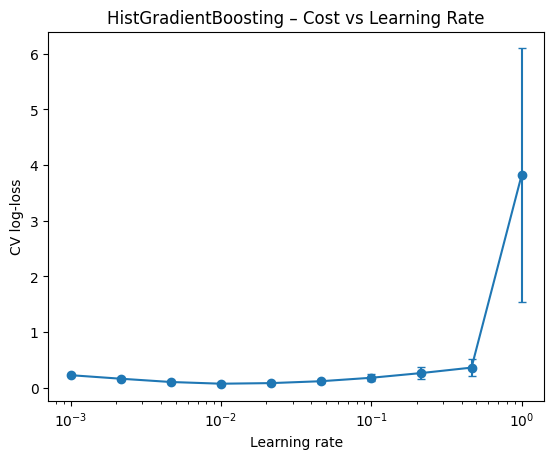

In [ ]:
from sklearn.model_selection import cross_val_score

# CV only uses training data (preserves time ordering integrity)
X = X_train.copy()
y = y_train.copy()

# Learning-rate sweep with CV log-loss
learning_rates = np.logspace(-3, 0, 10)   # 0.001 → 1.0

mean_costs = []
std_costs = []

for lr in learning_rates:
    base_model = HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=lr,
        max_iter=300,
        random_state=RANDOM_STATE
    )

    model = make_pipeline(preprocess, base_model)

    scores = cross_val_score(
        model,
        X, y,
        scoring="neg_log_loss",
        cv=5,
        n_jobs=-1
    )

    cost = -scores.mean()
    mean_costs.append(cost)
    std_costs.append(scores.std())

# Plot cost vs learning rate
plt.errorbar(learning_rates, mean_costs, yerr=std_costs, marker="o", capsize=3)
plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("CV log-loss")
plt.title("HistGradientBoosting – Cost vs Learning Rate")

best_idx = int(np.argmin(mean_costs))
print(f"Best learning_rate: {learning_rates[best_idx]:.6f}")
print(f"Minimum CV log-loss: {mean_costs[best_idx]:.6f}")